In [221]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [222]:
# Loading our attrition processed data into a pandas dataframe
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

# Visualizing top 5 records
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### **Exploratory Data Analysis**
#### **1. Where is attrition concentrated?**
- **Which job roles, departments, and job levels exceed the 16.1% baseline, and by enough to matter given their headcount?**

In [223]:
# Checking the overall attrition rate in the dataset
attrition_rate = (df["Attrition"] == "Yes").mean()
print(f"Overall attrition rate: {attrition_rate:.1%}")

Overall attrition rate: 16.1%


In [224]:
# Defining our attrition rate baseline
BASELINE = attrition_rate

In [225]:
# Creating a reusable attrition sumamry function for our analysis
def attrition_summary(df, column, baseline=BASELINE):
    summary = (
        df.groupby(column)
          .agg(
              Headcount=("EmployeeNumber", "size"),
              AttritionCount=("Attrition", lambda x: (x == "Yes").sum())
          )
    )

    # Calculate attrition rate as a percentage
    summary["AttritionRate"] = (
        summary["AttritionCount"] / summary["Headcount"] * 100
    )

    # Difference from company-wide baseline, in percentage points
    summary["DifferenceFromBaseline_pp"] = (
        summary["AttritionRate"] - (baseline * 100)
    )

    # How many times higher/lower than the baseline
    summary["RelativeToBaseline"] = (
        summary["AttritionRate"] / (baseline * 100)
    )

    return summary.sort_values(
        "AttritionRate",
        ascending=False
    )

In [226]:
# Checking attrition summary by JobRole
job_role_summary = attrition_summary(df, "JobRole")

# Formating the dataframe values for better data analysis readability
job_role_summary.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
JobRole,,,,,
Sales Representative,83,33,39.76%,+23.64 pp,2.47x
Laboratory Technician,259,62,23.94%,+7.82 pp,1.48x
Human Resources,52,12,23.08%,+6.95 pp,1.43x
Sales Executive,326,57,17.48%,+1.36 pp,1.08x
Research Scientist,292,47,16.10%,-0.03 pp,1.00x
Manufacturing Director,145,10,6.90%,-9.23 pp,0.43x
Healthcare Representative,131,9,6.87%,-9.25 pp,0.43x
Manager,102,5,4.90%,-11.22 pp,0.30x
Research Director,80,2,2.50%,-13.62 pp,0.16x


In [227]:
# Checking attrition summary by Department
department_summary = attrition_summary(df, "Department")

# Formating the dataframe values for better data analysis readability
department_summary.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
Department,,,,,
Sales,446,92,20.63%,+4.51 pp,1.28x
Human Resources,63,12,19.05%,+2.93 pp,1.18x
Research & Development,961,133,13.84%,-2.28 pp,0.86x


In [228]:
# Checking attrition summary by JobLevel
job_level_summary = attrition_summary(df, "JobLevel")

# Formating the dataframe values for better data analysis readability
job_level_summary.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
JobLevel,,,,,
1,543,143,26.34%,+10.21 pp,1.63x
3,218,32,14.68%,-1.44 pp,0.91x
2,534,52,9.74%,-6.38 pp,0.60x
5,69,5,7.25%,-8.88 pp,0.45x
4,106,5,4.72%,-11.41 pp,0.29x


In [229]:
# To better analyse the organizational impact of the JobRole attrition rate, we'll add a new attribute for Excess attrition
# Through Excess attrition we can analyse how many more employees left than we would expect if this group had the company-wide baseline?
# Expected Attrition = Headcount*BASELINE
# Excess Attrition=Actual Attrition−Expected Attrition

job_role_summary["ExpectedAttrition"] = (
    job_role_summary["Headcount"] * BASELINE
)

job_role_summary["ExcessAttrition"] = (
    job_role_summary["AttritionCount"] -
    job_role_summary["ExpectedAttrition"]
)

job_role_summary.sort_values(
    "ExcessAttrition",
    ascending=False
)

job_role_summary.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
    "ExpectedAttrition": "{:,.0f}",
    "ExcessAttrition": "{:+,.0f}"
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline,ExpectedAttrition,ExcessAttrition
JobRole,,,,,,,
Sales Representative,83,33,39.76%,+23.64 pp,2.47x,13,+20
Laboratory Technician,259,62,23.94%,+7.82 pp,1.48x,42,+20
Human Resources,52,12,23.08%,+6.95 pp,1.43x,8,+4
Sales Executive,326,57,17.48%,+1.36 pp,1.08x,53,+4
Research Scientist,292,47,16.10%,-0.03 pp,1.00x,47,-0
Manufacturing Director,145,10,6.90%,-9.23 pp,0.43x,23,-13
Healthcare Representative,131,9,6.87%,-9.25 pp,0.43x,21,-12
Manager,102,5,4.90%,-11.22 pp,0.30x,16,-11
Research Director,80,2,2.50%,-13.62 pp,0.16x,13,-11


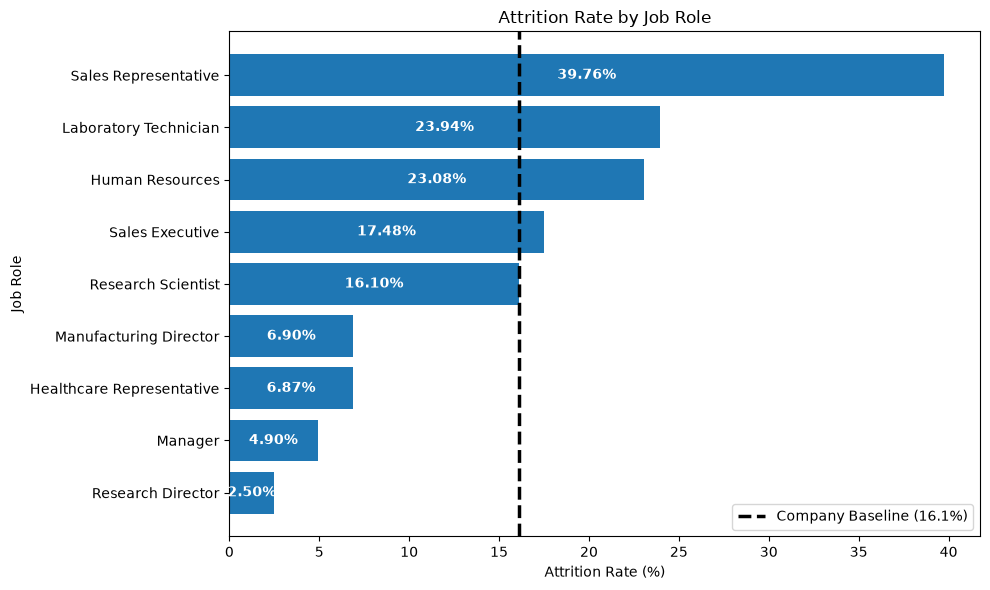

In [230]:
# Visualizing the JobRoles above the Attrition Rate Baseline (16.1%)
roles_above_baseline = (
    job_role_summary
    .sort_values("AttritionRate", ascending=True)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    roles_above_baseline.index,
    roles_above_baseline["AttritionRate"]
)

# Add labels inside the bars
for bar, rate, headcount in zip(
    bars,
    roles_above_baseline["AttritionRate"],
    roles_above_baseline["Headcount"]
):
    plt.text(
        bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.2f}%",
        ha="center",
        va="center",
        fontweight="bold",
        color="white"
    )

# Company baseline
plt.axvline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.title("Attrition Rate by Job Role")

plt.legend()
plt.tight_layout()
plt.show()

In [231]:
# Calculating the ExpectedAttrition and ExcessAttrition per department
department_summary["ExpectedAttrition"] = (
    department_summary["Headcount"] * BASELINE
)

department_summary["ExcessAttrition"] = (
    department_summary["AttritionCount"] -
    department_summary["ExpectedAttrition"]
)

department_summary.sort_values(
    "ExcessAttrition",
    ascending=False
)

department_summary.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
    "ExpectedAttrition": "{:,.0f}",
    "ExcessAttrition": "{:+,.0f}"
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline,ExpectedAttrition,ExcessAttrition
Department,,,,,,,
Sales,446,92,20.63%,+4.51 pp,1.28x,72,+20
Human Resources,63,12,19.05%,+2.93 pp,1.18x,10,+2
Research & Development,961,133,13.84%,-2.28 pp,0.86x,155,-22


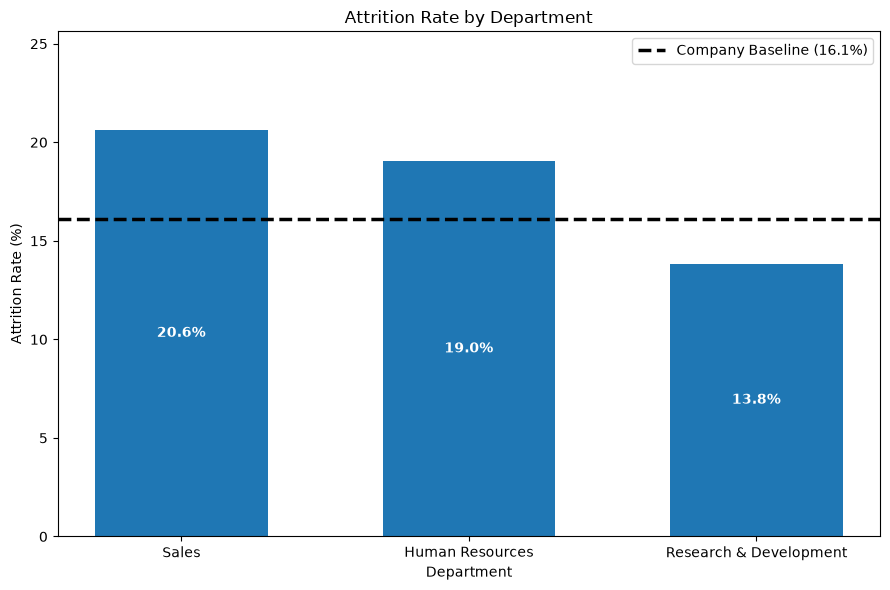

In [232]:
# Visualizing the Departments above the Attrition Rate Baseline (16.1%)
department_plot = department_summary.copy()

# Sort by attrition rate
department_plot = department_plot.sort_values(
    "AttritionRate",
    ascending=False
)

plt.figure(figsize=(9, 6))

# Bars
bars = plt.bar(
    department_plot.index,
    department_plot["AttritionRate"],
    width=0.6
)

# Company baseline
plt.axhline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

# Labels inside bars
for bar, rate, headcount in zip(
    bars,
    department_plot["AttritionRate"],
    department_plot["Headcount"]
):
    if rate >= 8:
        # Place label inside the bar
        y = bar.get_height() / 2
        va = "center"
        text_color = "white"
    else:
        # Place label above very short bars
        y = bar.get_height() + 0.3
        va = "bottom"
        text_color = "black"

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f"{rate:.1f}%",
        ha="center",
        va=va,
        fontweight="bold",
        color=text_color
    )

plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
plt.title("Attrition Rate by Department")

plt.ylim(
    0,
    department_plot["AttritionRate"].max() + 5
)

plt.legend()
plt.tight_layout()
plt.show()

In [233]:
# Calculating the ExpectedAttrition and ExcessAttrition per job level
job_level_summary["ExpectedAttrition"] = (
    job_level_summary["Headcount"] * BASELINE
)

job_level_summary["ExcessAttrition"] = (
    job_level_summary["AttritionCount"] -
    job_level_summary["ExpectedAttrition"]
)

job_level_summary.sort_values(
    "ExcessAttrition",
    ascending=False
)

job_level_summary.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
    "ExpectedAttrition": "{:,.0f}",
    "ExcessAttrition": "{:+,.0f}"
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline,ExpectedAttrition,ExcessAttrition
JobLevel,,,,,,,
1,543,143,26.34%,+10.21 pp,1.63x,88,+55
3,218,32,14.68%,-1.44 pp,0.91x,35,-3
2,534,52,9.74%,-6.38 pp,0.60x,86,-34
5,69,5,7.25%,-8.88 pp,0.45x,11,-6
4,106,5,4.72%,-11.41 pp,0.29x,17,-12


In [234]:
# Before visualizing JobLevel that exceeded the baseline rate we'll categorize them
job_level_labels = {
    1: "1 - Entry",
    2: "2 - Junior",
    3: "3 - Intermediate",
    4: "4 - Senior",
    5: "5 - Leadership"
}

# Create a copy for visualization
job_level_plot = job_level_summary.copy()

# Replace numeric index with descriptive labels
job_level_plot.index = job_level_plot.index.map(job_level_labels)

# Define the desired order
job_level_order = [
    "1 - Entry",
    "3 - Intermediate",
    "2 - Junior",    
    "5 - Leadership",
    "4 - Senior"
]

# Reorder the rows
job_level_plot = job_level_plot.reindex(job_level_order)

job_level_plot.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
    "ExpectedAttrition": "{:,.0f}",
    "ExcessAttrition": "{:+,.0f}"
})


,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline,ExpectedAttrition,ExcessAttrition
JobLevel,,,,,,,
1 - Entry,543,143,26.34%,+10.21 pp,1.63x,88,+55
3 - Intermediate,218,32,14.68%,-1.44 pp,0.91x,35,-3
2 - Junior,534,52,9.74%,-6.38 pp,0.60x,86,-34
5 - Leadership,69,5,7.25%,-8.88 pp,0.45x,11,-6
4 - Senior,106,5,4.72%,-11.41 pp,0.29x,17,-12


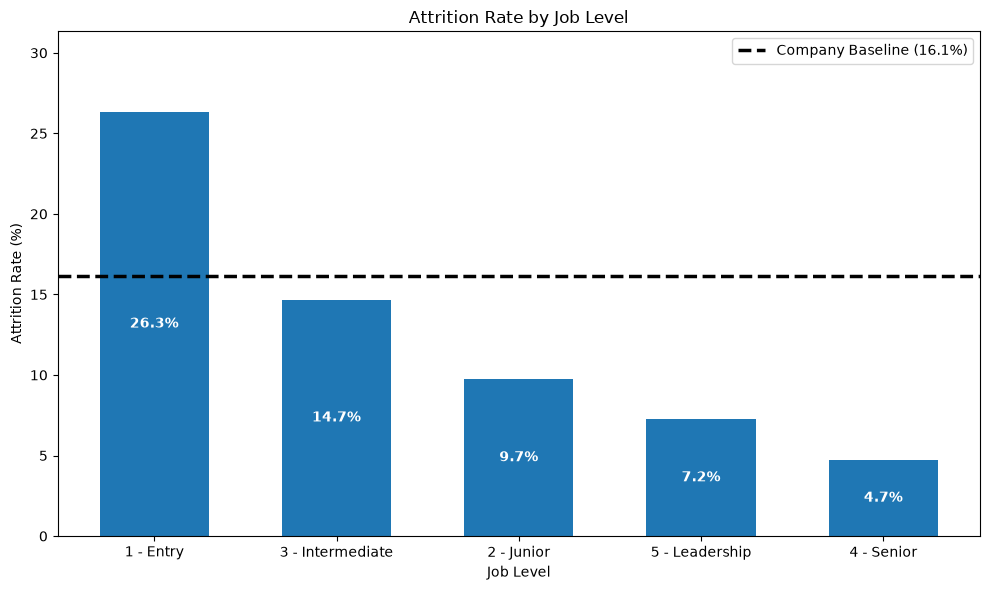

In [235]:
# Visualizing the JobLevel(s) above the Attrition Rate Baseline (16.1%)
plt.figure(figsize=(10, 6))

bars = plt.bar(
    job_level_plot.index,
    job_level_plot["AttritionRate"],
    width=0.6
)

# Company baseline
plt.axhline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

# Labels inside bars
for bar, rate, headcount in zip(
    bars,
    job_level_plot["AttritionRate"],
    job_level_plot["Headcount"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{rate:.1f}%",
        ha="center",
        va="center",
        fontweight="bold",
        color="white"
    )

plt.xlabel("Job Level")
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Job Level")

plt.ylim(
    0,
    max(job_level_plot["AttritionRate"]) + 5
)

plt.legend()
plt.tight_layout()
plt.show()

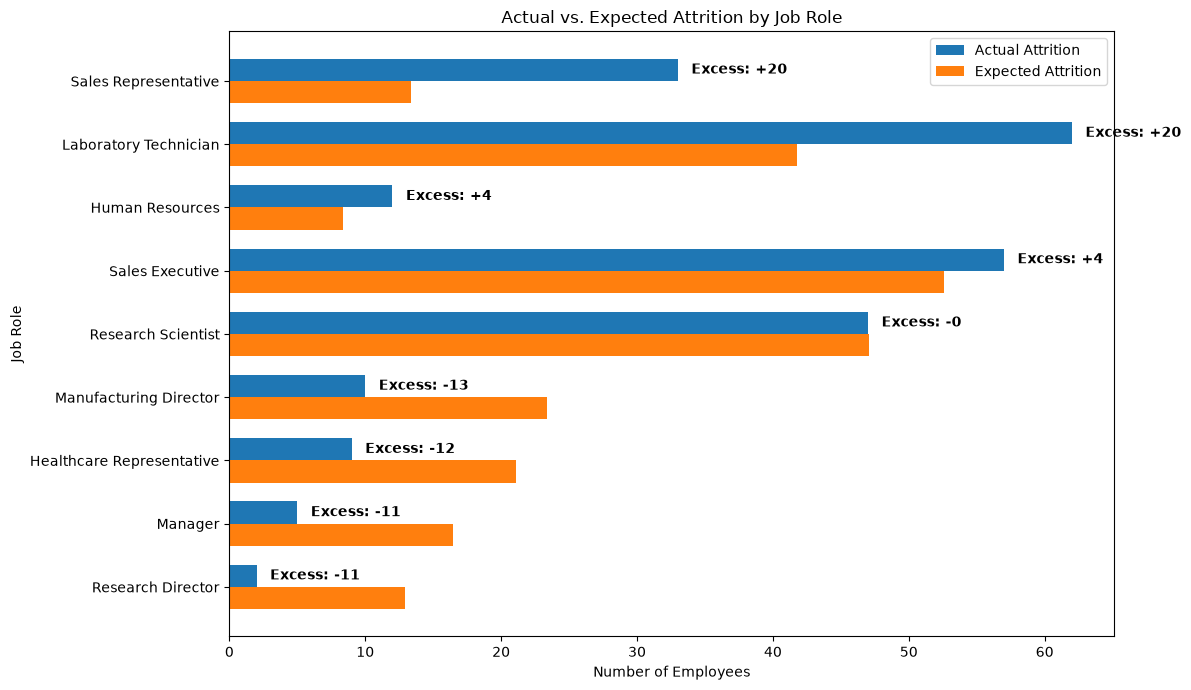

In [236]:
#  Visualizing histogram with AttritionCount, ExpectedAttirion and ExcessAttrition by Job Role
# Sort by actual attrition
job_role_plot = (
    job_role_summary
    .sort_values("AttritionRate", ascending=True)
)

y = np.arange(len(job_role_plot))
height = 0.35

plt.figure(figsize=(12, 7))

# Actual attrition
plt.barh(
    y + height / 2,
    job_role_plot["AttritionCount"],
    height,
    label="Actual Attrition"
)

# Expected attrition
plt.barh(
    y - height / 2,
    job_role_plot["ExpectedAttrition"],
    height,
    label="Expected Attrition"
)

# Excess attrition labels
for i, (actual, excess) in enumerate(
    zip(
        job_role_plot["AttritionCount"],
        job_role_plot["ExcessAttrition"]
    )
):
    plt.text(
        actual + 1,
        i + height / 2,
        f"Excess: {excess:+.0f}",
        va="center",
        fontweight="bold"
    )

plt.yticks(
    y,
    job_role_plot.index
)

plt.xlabel("Number of Employees")
plt.ylabel("Job Role")
plt.title("Actual vs. Expected Attrition by Job Role")

plt.legend()
plt.tight_layout()
plt.show()

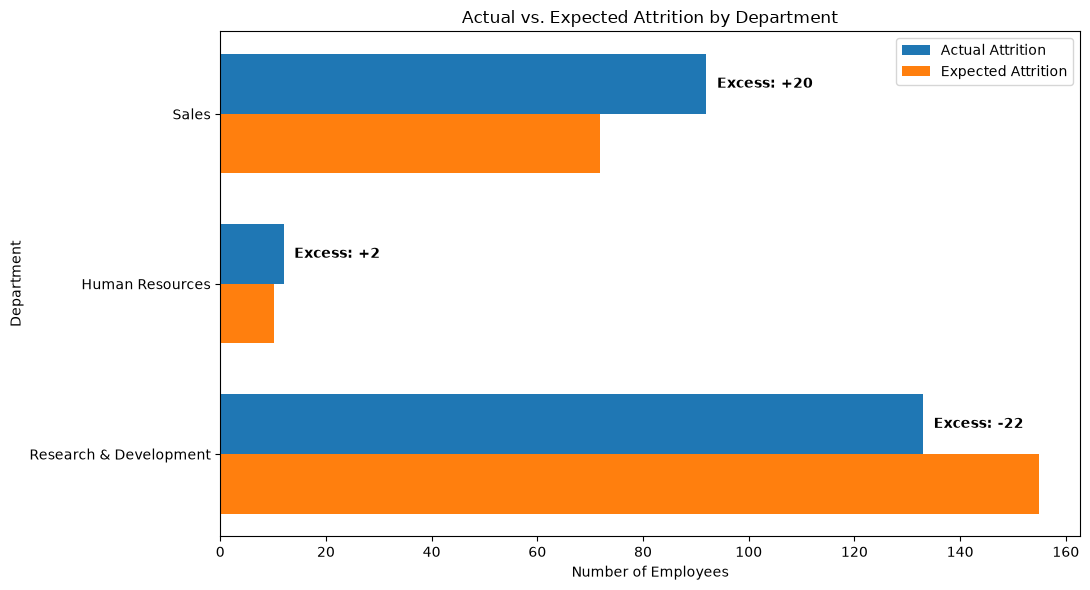

In [237]:
#  Visualizing histogram with AttritionCount, ExpectedAttrition and ExcessAttrition by Department
# Sort departments by actual attrition count
department_plot = (
    department_summary
    .sort_values("AttritionRate", ascending=True)
)

y = np.arange(len(department_plot))
height = 0.35
plt.figure(figsize=(11, 6))

# Actual Attrition
bars_actual = plt.barh(
    y + height / 2,
    department_plot["AttritionCount"],
    height,
    label="Actual Attrition"
)

# Expected Attrition
bars_expected = plt.barh(
    y - height / 2,
    department_plot["ExpectedAttrition"],
    height,
    label="Expected Attrition"
)

# Excess Attrition labels
for i, (actual, excess) in enumerate(
    zip(
        department_plot["AttritionCount"],
        department_plot["ExcessAttrition"]
    )
):
    plt.text(
        actual + 2,
        i + height / 2,
        f"Excess: {excess:+.0f}",
        va="center",
        fontweight="bold"

    )


plt.yticks(
    y,
    department_plot.index
)

plt.xlabel("Number of Employees")
plt.ylabel("Department")
plt.title("Actual vs. Expected Attrition by Department")


plt.legend()


plt.tight_layout()
plt.show()

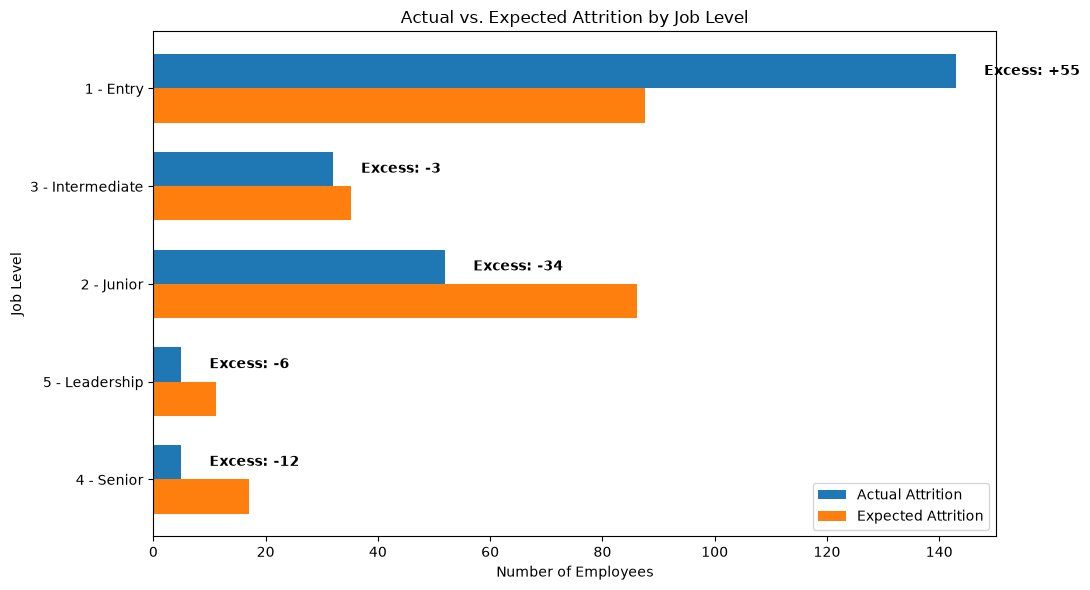

In [238]:
#  Visualizing histogram with AttritionCount, ExpectedAttrition and ExcessAttrition by JobLevel
# Sort departments by actual attrition count
job_level_plot = (
    job_level_plot
    .sort_values("AttritionRate", ascending=True)
)

y = np.arange(len(job_level_plot))
height = 0.35

plt.figure(figsize=(11, 6))

# Actual Attrition
bars_actual = plt.barh(
    y + height / 2,
    job_level_plot["AttritionCount"],
    height,
    label="Actual Attrition"
)

# Expected Attrition
bars_expected = plt.barh(
    y - height / 2,
    job_level_plot["ExpectedAttrition"],
    height,
    label="Expected Attrition"
)

# Add Excess Attrition labels
for i, (actual, excess) in enumerate(
    zip(
        job_level_plot["AttritionCount"],
        job_level_plot["ExcessAttrition"]
    )
):
    plt.text(
        actual + 5,
        i + height / 2,
        f"Excess: {excess:+.0f}",
        va="center",
        fontweight="bold"
    )

plt.yticks(
    y,
    job_level_plot.index
)


plt.xlabel("Number of Employees")
plt.ylabel("Job Level")
plt.title("Actual vs. Expected Attrition by Job Level")

plt.legend()
plt.tight_layout()
plt.show()

#### **Conclusion:**

The exploratory analysis shows that attrition is concentrated primarily among **Entry Level jobs**, with a 26.3% attrition rate and approximately **55 excess departures** compared with the 16.1% company baseline. Among job roles, **Sales Representatives (39.76%)** and **Laboratory Technicians (23.94%)** show the highest attrition rates and approximately **20 excess departures each**, making them the most significant areas of concern given their headcount. **Human Resources (23.08%)** and **Sales Executive (17.48%)** also exceeds the baseline, although its smaller workforce results in a lower overall impact.

At the department level, the analysis identifies the areas where attrition exceeds the company baseline, while the Actual vs. Expected comparisons help distinguish high rates from areas with meaningful numbers of additional departures. Overall, the findings suggest that **early-career employees and specific operational roles are the primary concentrations of attrition**, providing clear areas for further investigation into retention factors such as tenure, compensation, workload, and job satisfaction.


#### **2. Is attrition an early-tenure phenomenon, a mid-career phenomenon, or both?**

In [239]:
# For tenure (How long an employee has worked for a company in a particular position) we must understand how employess are distributed across YearsAtCompany
df["YearsAtCompany"].describe()

count    1470.000000
mean        7.008163
std         6.126525
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        40.000000
Name: YearsAtCompany, dtype: float64

In [240]:
# Exploring individual values for tenure
df["YearsAtCompany"].value_counts().sort_index()

YearsAtCompany
0      44
1     171
2     127
3     128
4     110
5     196
6      76
7      90
8      80
9      82
10    120
11     32
12     14
13     24
14     18
15     20
16     12
17      9
18     13
19     11
20     27
21     14
22     15
23      2
24      6
25      4
26      4
27      2
29      2
30      1
31      3
32      3
33      5
34      1
36      2
37      1
40      1
Name: count, dtype: int64

In [241]:
# For better analysis and visualization we'll create meaningful groups for tenure instead of analysing individual YearsAtCompany
tenure_bins = [-1, 2, 5, 10, float("inf")]

tenure_labels = [
    "0–2 years",
    "3–5 years",
    "6–10 years",
    "11+ years"
]

df["TenureGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=tenure_bins,
    labels=tenure_labels
)

df[["Age","Attrition","Department","YearsAtCompany","TenureGroup"]].head()

,Age,Attrition,Department,YearsAtCompany,TenureGroup
0,41,Yes,Sales,6,6–10 years
1,49,No,Research & Development,10,6–10 years
2,37,Yes,Research & Development,0,0–2 years
3,33,No,Research & Development,8,6–10 years
4,27,No,Research & Development,2,0–2 years


In [242]:
# Calculating the attrition summary by tenure group
tenure_summary = attrition_summary(df, "TenureGroup")

# Formating the dataframe values for better data analysis readability
tenure_summary.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
    "ExpectedAttrition": "{:,.0f}",
    "ExcessAttrition": "{:+,.0f}"
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
TenureGroup,,,,,
0–2 years,342,102,29.82%,+13.70 pp,1.85x
3–5 years,434,60,13.82%,-2.30 pp,0.86x
6–10 years,448,55,12.28%,-3.85 pp,0.76x
11+ years,246,20,8.13%,-7.99 pp,0.50x


In [243]:
# Adding the ExpectedAttrition and ExcessAttrition by Tenure Group
tenure_summary["ExpectedAttrition"] = (
    tenure_summary["Headcount"] * BASELINE
)

tenure_summary["ExcessAttrition"] = (
    tenure_summary["AttritionCount"] -
    tenure_summary["ExpectedAttrition"]
)

tenure_summary.sort_values(
    "ExcessAttrition",
    ascending=False
)

tenure_summary.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
    "ExpectedAttrition": "{:,.0f}",
    "ExcessAttrition": "{:+,.0f}"
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline,ExpectedAttrition,ExcessAttrition
TenureGroup,,,,,,,
0–2 years,342,102,29.82%,+13.70 pp,1.85x,55,+47
3–5 years,434,60,13.82%,-2.30 pp,0.86x,70,-10
6–10 years,448,55,12.28%,-3.85 pp,0.76x,72,-17
11+ years,246,20,8.13%,-7.99 pp,0.50x,40,-20


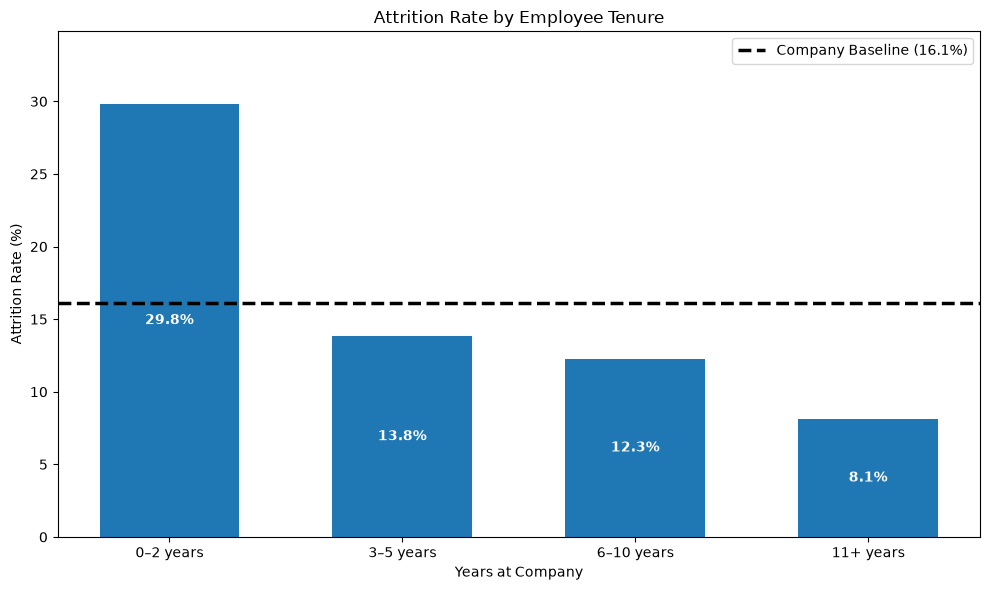

In [244]:
# Visualizing the AttritionRate by Tenure
tenure_plot = tenure_summary.copy()

plt.figure(figsize=(10, 6))

bars = plt.bar(
    tenure_plot.index,
    tenure_plot["AttritionRate"],
    width=0.6
)

# Company baseline
plt.axhline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

# Labels
for bar, rate, headcount in zip(
    bars,
    tenure_plot["AttritionRate"],
    tenure_plot["Headcount"]
):
    if rate >= 8:
        y = bar.get_height() / 2
        va = "center"
        text_color = "white"
    else:
        y = bar.get_height() + 0.3
        va = "bottom"
        text_color = "black"

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f"{rate:.1f}%",
        ha="center",
        va=va,
        fontweight="bold",
        color=text_color
    )

plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Employee Tenure")

plt.ylim(
    0,
    tenure_plot["AttritionRate"].max() + 5
)

plt.legend()

plt.tight_layout()
plt.show()

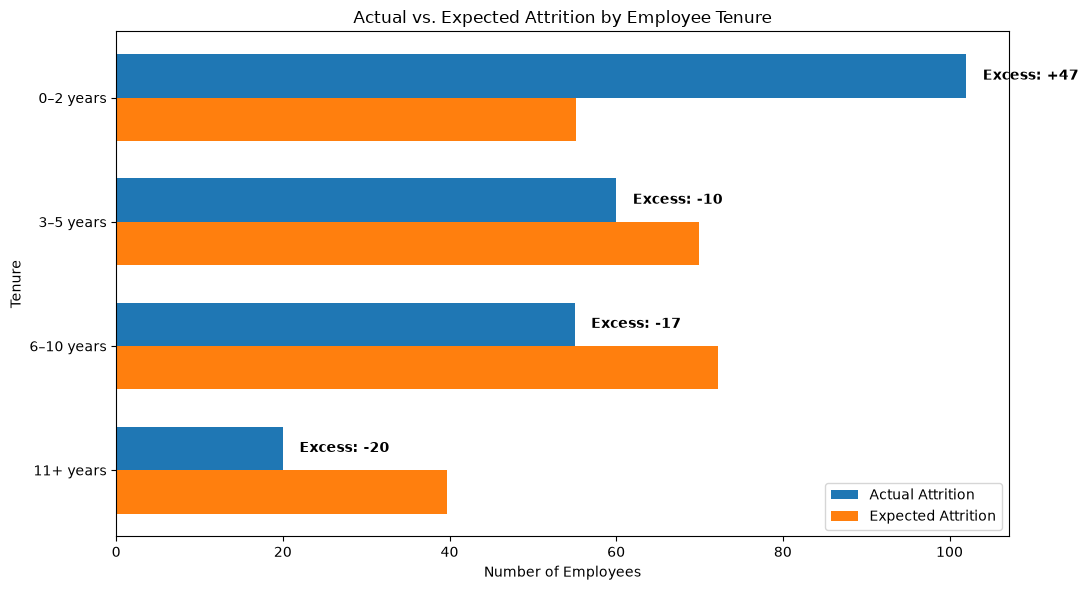

In [245]:
# Visualizing the Actual vs Expected Attrition by TenureGroup
tenure_plot = tenure_summary.copy()

tenure_plot = (
    tenure_plot
    .sort_values("AttritionRate", ascending=True)
)

y = np.arange(len(tenure_plot))
height = 0.35

plt.figure(figsize=(11, 6))

# Actual
bars_actual = plt.barh(
    y + height / 2,
    tenure_plot["AttritionCount"],
    height,
    label="Actual Attrition"
)

# Expected
bars_expected = plt.barh(
    y - height / 2,
    tenure_plot["ExpectedAttrition"],
    height,
    label="Expected Attrition"
)

# Excess labels
for i, (actual, excess) in enumerate(
    zip(
        tenure_plot["AttritionCount"],
        tenure_plot["ExcessAttrition"]
    )
):
    plt.text(
        actual + 2,
        i + height / 2,
        f"Excess: {excess:+.0f}",
        va="center",
        fontweight="bold"
    )

plt.yticks(
    y,
    tenure_plot.index
)

plt.xlabel("Number of Employees")
plt.ylabel("Tenure")
plt.title("Actual vs. Expected Attrition by Employee Tenure")

plt.legend()

plt.tight_layout()
plt.show()

In [246]:
# Checking the attrition rate along the years at company
tenure_by_year = (
    df.groupby("YearsAtCompany")
      .agg(
          Headcount=("EmployeeNumber", "size"),
          AttritionCount=("Attrition", lambda x: (x == "Yes").sum())
      )
)

tenure_by_year["AttritionRate"] = (
    tenure_by_year["AttritionCount"] /
    tenure_by_year["Headcount"] * 100
)

tenure_by_year.style.format({
    "AttritionRate": "{:.2f}%",
})

,Headcount,AttritionCount,AttritionRate
YearsAtCompany,,,
0,44,16,36.36%
1,171,59,34.50%
2,127,27,21.26%
3,128,20,15.62%
4,110,19,17.27%
5,196,21,10.71%
6,76,9,11.84%
7,90,11,12.22%
8,80,9,11.25%


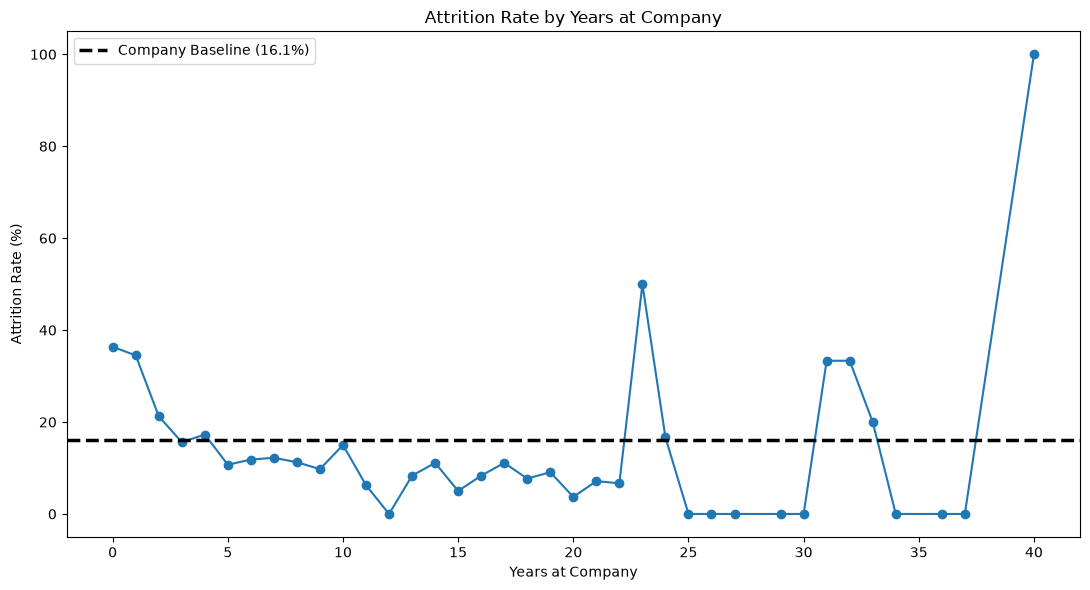

In [247]:
# Visualizing a Linechart with the attrition rate along the years at the company
plt.figure(figsize=(11, 6))

plt.plot(
    tenure_by_year.index,
    tenure_by_year["AttritionRate"],
    marker="o"
)

plt.axhline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Years at Company")

plt.legend()

plt.tight_layout()
plt.show()

In [248]:
# Investigating the YearsInCurrentRole
# This can help to identify if the attrition is associated with employees spending a long time in the same role?
# For example: An employee might have been with the company for 8 years but only in their current role for 1 year.
role_tenure_summary = (
    df.groupby("YearsInCurrentRole")
      .agg(
          Headcount=("EmployeeNumber", "size"),
          AttritionCount=("Attrition", lambda x: (x == "Yes").sum())
      )
)

role_tenure_summary["AttritionRate"] = (
    role_tenure_summary["AttritionCount"] /
    role_tenure_summary["Headcount"] * 100
)

role_tenure_summary.style.format({
    "AttritionRate": "{:.2f}%",
})

,Headcount,AttritionCount,AttritionRate
YearsInCurrentRole,,,
0,244,73,29.92%
1,57,11,19.30%
2,372,68,18.28%
3,135,16,11.85%
4,104,15,14.42%
5,36,1,2.78%
6,37,2,5.41%
7,222,31,13.96%
8,89,7,7.87%


In [249]:
# Grouping YearsInCurrentRole into meaningful bucket
role_tenure_bins = [-1, 1, 3, 5, 10, float("inf")]
role_tenure_labels = [
    "0–1 years",
    "2–3 years",
    "4–5 years",
    "6–10 years",
    "11+ years"
]

df["CurrentRoleGroup"] = pd.cut(
    df["YearsInCurrentRole"],
    bins=role_tenure_bins,
    labels=role_tenure_labels
)

role_tenure_summary = attrition_summary(
    df,
    "CurrentRoleGroup"
)

role_tenure_summary.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
CurrentRoleGroup,,,,,
0–1 years,301,84,27.91%,+11.78 pp,1.73x
2–3 years,507,84,16.57%,+0.45 pp,1.03x
4–5 years,140,16,11.43%,-4.69 pp,0.71x
6–10 years,444,48,10.81%,-5.31 pp,0.67x
11+ years,78,5,6.41%,-9.71 pp,0.40x


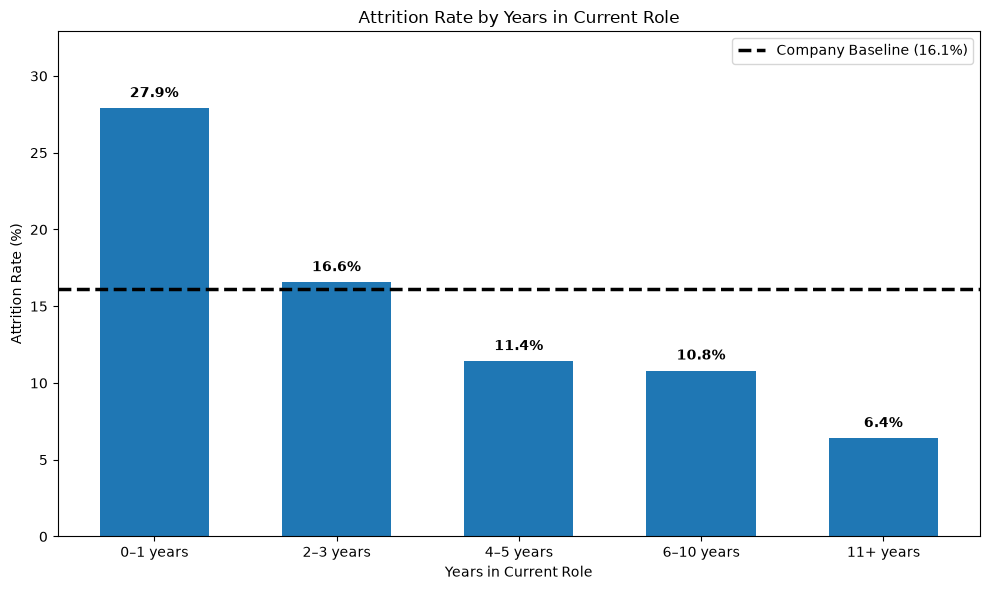

In [250]:
# Visualizing the attrition rate by years in current role
plot_data = role_tenure_summary.sort_values("AttritionRate", ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    plot_data.index,
    plot_data["AttritionRate"],
    width=0.6
)

plt.axhline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

for bar, rate, headcount in zip(
    bars,
    plot_data["AttritionRate"],
    plot_data["Headcount"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.ylabel("Attrition Rate (%)")
plt.xlabel("Years in Current Role")
plt.title("Attrition Rate by Years in Current Role")
plt.ylim(0, plot_data["AttritionRate"].max() + 5)
plt.legend()
plt.tight_layout()
plt.show()

In [251]:
# Investigating YearsWithCurrManager
# This can help to identify whether attrition is concentrated among employees who have spent very litle or very long time with their current manager
manager_tenure_bins = [-1, 1, 3, 5, 10, float("inf")]
manager_tenure_labels = [
    "0–1 years",
    "2–3 years",
    "4–5 years",
    "6–10 years",
    "11+ years"
]

df["ManagerTenureGroup"] = pd.cut(
    df["YearsWithCurrManager"],
    bins=manager_tenure_bins,
    labels=manager_tenure_labels
)

manager_tenure_summary = attrition_summary(
    df,
    "ManagerTenureGroup"
)

manager_tenure_summary.style.format({
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
ManagerTenureGroup,,,,,
0–1 years,339,96,28.32%,+12.20 pp,1.76x
2–3 years,486,69,14.20%,-1.92 pp,0.88x
6–10 years,443,54,12.19%,-3.93 pp,0.76x
4–5 years,129,15,11.63%,-4.49 pp,0.72x
11+ years,73,3,4.11%,-12.01 pp,0.25x


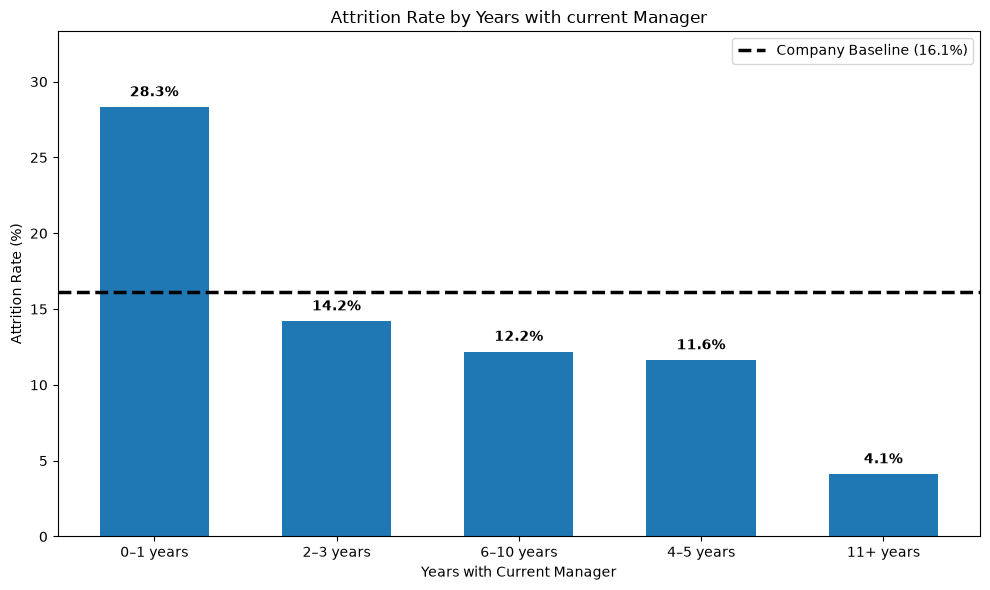

In [252]:
# Visualizing the attrition rate by years in current manager
plot_data = manager_tenure_summary.sort_values("AttritionRate", ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    plot_data.index,
    plot_data["AttritionRate"],
    width=0.6
)

plt.axhline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

for bar, rate, headcount in zip(
    bars,
    plot_data["AttritionRate"],
    plot_data["Headcount"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.ylabel("Attrition Rate (%)")
plt.xlabel("Years with Current Manager")
plt.title("Attrition Rate by Years with current Manager")
plt.ylim(0, plot_data["AttritionRate"].max() + 5)
plt.legend()
plt.tight_layout()
plt.show()

In [253]:
# Investigating the TotalWorkingYears to differenciate "new to company" from "early career"
experience_bins = [-1, 2, 5, 10, 20, float("inf")]
experience_labels = [
    "0–2 years",
    "3–5 years",
    "6–10 years",
    "11–20 years",
    "21+ years"
]

df["ExperienceGroup"] = pd.cut(
    df["TotalWorkingYears"],
    bins=experience_bins,
    labels=experience_labels
)

experience_summary = attrition_summary(
    df,
    "ExperienceGroup"
)

experience_summary.style.format({
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
ExperienceGroup,,,,,
0–2 years,123,54,43.90%,+27.78 pp,2.72x
3–5 years,193,37,19.17%,+3.05 pp,1.19x
6–10 years,607,91,14.99%,-1.13 pp,0.93x
11–20 years,340,39,11.47%,-4.65 pp,0.71x
21+ years,207,16,7.73%,-8.39 pp,0.48x


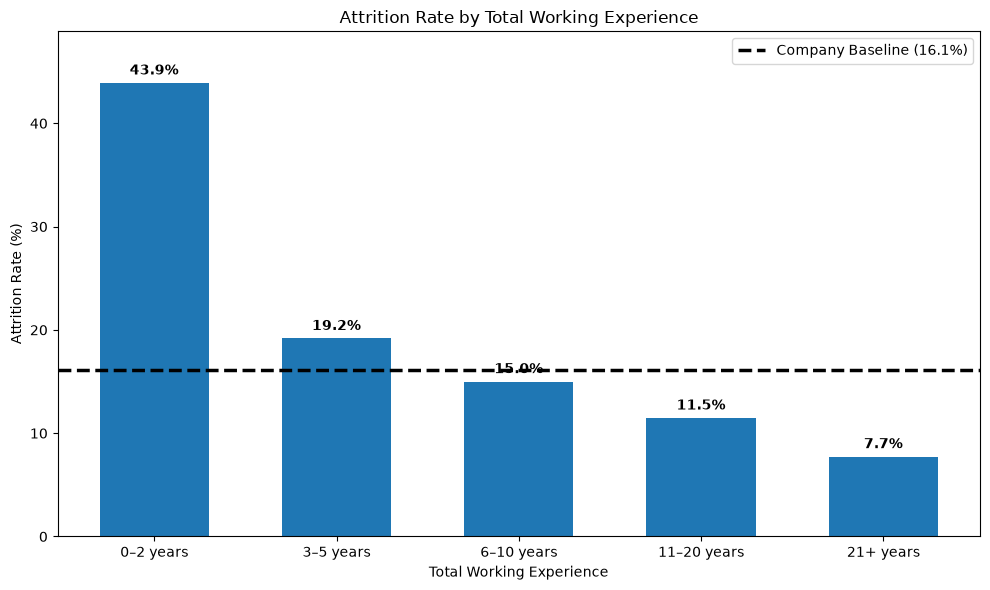

In [254]:
# Visualizing the Attrition Rate by Total Working Experience
plot_data = experience_summary.sort_values("AttritionRate", ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    plot_data.index,
    plot_data["AttritionRate"],
    width=0.6
)

plt.axhline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

for bar, rate, headcount in zip(
    bars,
    plot_data["AttritionRate"],
    plot_data["Headcount"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.ylabel("Attrition Rate (%)")
plt.xlabel("Total Working Experience")
plt.title("Attrition Rate by Total Working Experience")
plt.ylim(0, plot_data["AttritionRate"].max() + 5)
plt.legend()
plt.tight_layout()
plt.show()

#### **Conclusion:**

**Attrition is primarily an early-tenure phenomenon** rather than a mid-career phenomenon. Employees with 0–2 years at the company have a 29.82% attrition rate, compared with the 16.1% baseline, and attrition declines consistently with longer company tenure. This pattern is reinforced by the 27.91% attrition rate among employees with 0-1 year in their current role and the 28.32% rate among those with 0–1 years with their current manager. Overall career experience shows a similar pattern, with attrition highest among employees with 0–2 years of total experience (43.90%) and declining to 7.73% for those with 21+ years. Therefore, the evidence strongly points to early-career and early-organizational tenure as the primary attrition risk period, with little evidence that attrition is primarily a mid-career phenomenon.